[Chapter 5](05_Detecting_Stationarity.ipynb) gave us a toolbox for *removing* structure: difference away a trend, seasonally difference away a cycle, take logs to tame a spreading variance. Every one of those transformations throws structure away so that what is left is stationary and modellable.

Smoothing pulls in the opposite direction. It **keeps** the structure and throws the *noise* away.
The working assumption is that every observation is the sum of two things,

$$X(t) = \underbrace{\text{pattern}(t)}_{\text{slow, want it}} \;+\; \underbrace{\varepsilon(t)}_{\text{fast, want rid of it}},$$

and that the pattern changes slowly enough that neighbouring observations carry information about it, while the noise is unpredictable and averages out. Local averaging therefore recovers the pattern. 
Push that recovered pattern one step past the end of the data and the same machinery becomes a **forecaster**, and the forecasters in this chapter (Holt-Winters in particular) remain hard baselines to beat in practice.

# Learning objectives

By the end of this lecture you should be able to:

1. State the signal-plus-noise assumption behind smoothing, and use a smoother for its two distinct purposes: **filtering** a series and **forecasting** it.
2. Compute a **simple average**, a **moving average** and a **weighted moving average**, and handle the two things that trip people up: **alignment** (centred vs trailing) and the **shortened output**.
3. Explain the **responsiveness / robustness** tradeoff, and show that a trailing $P$-point moving-average forecast lags the signal by $\tfrac{P+1}{2}$ steps.
4. Write down the **single**, **double** and **triple** exponential smoothing recursions, say which component each one captures, and choose between **additive** and **multiplicative** seasonality.
5. Fit all three in `statsmodels`, read the estimated smoothing parameters, and score forecasts on a **held-out test set** with the MSE.

# Setup

Modules and functions used in this lecture.

| Module | Used for |
|---|---|
| `numpy` | `random.default_rng`, `cumsum`, `convolve`, `full` |
| `pandas` | `read_csv`, `DataFrame`, `Series.ewm`, `asfreq` |
| `matplotlib.pyplot` | `subplots`, `plot`, `bar` |
| `statsmodels.tsa.api` | **`SimpleExpSmoothing`** (single), **`Holt`** (double), **`ExponentialSmoothing`** (triple / Holt-Winters) |

Everything else -- the moving averages, the MSE, the plotting helper -- we write ourselves, because the whole
point of this chapter is that the mechanics are simple enough to see through.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing

# statsmodels emits a ConvergenceWarning whenever the optimizer stops at a bound
# (alpha = 1 is a common and perfectly legitimate answer on short toy series).

rng = np.random.default_rng(0)   # reproducibility

The same run-sequence helper used in [Chapter 5](05_Detecting_Stationarity.ipynb): value against time,
returning the axes so we can keep drawing on them.

In [2]:
def run_sequence_plot(y, x=None, title="", xlabel="time", ylabel="value",
                      ax=None, figsize=(9, 3), color="blue", **kwargs):
    "Plot a series against time and return the axes."
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    if x is None:
        x = getattr(y, "index", np.arange(len(y)))
    ax.plot(x, y, color=color, lw=1, **kwargs)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.grid(alpha=0.3)
    return ax

## Four cases of time series

We need data whose components we *know*, so that we can tell whether a smoother recovered them.
Four series, built from the same noise draw so the comparisons are fair:

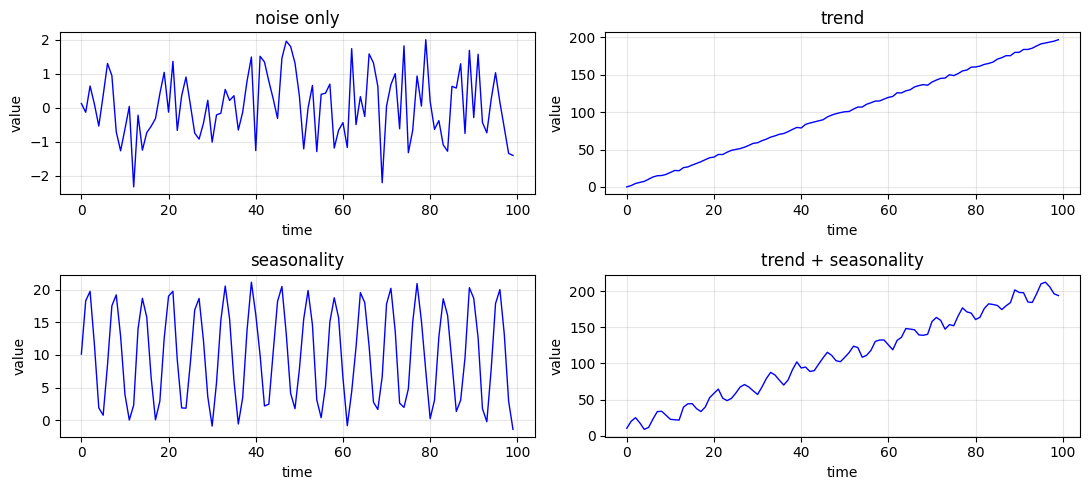

In [3]:
time = np.arange(100)

noise             = rng.normal(loc=0.0, scale=1.0, size=len(time))   # stationary, no structure
trend             = 2.0 * time + noise                               # linear trend + noise
seasonality       = 10 + 10 * np.sin(time) + noise                   # periodic + noise
trend_seasonality = trend + seasonality + noise                      # both, plus extra noise

_, axes = plt.subplots(2, 2, figsize=(11, 5))
for ax, (y, name) in zip(axes.ravel(), [(noise, "noise only"),
                                        (trend, "trend"),
                                        (seasonality, "seasonality"),
                                        (trend_seasonality, "trend + seasonality")]):
    run_sequence_plot(y, time, title=name, ax=ax)
plt.tight_layout();

# Smoothing and simple smoothing techniques

- A data collection process is often affected by noise. 
- If too strong, the noise can conceal useful patterns in the data. 
- Smoothing is a well-known and often-used technique to recover those patterns by *filtering out noise*.
- It can also be used to *make forecasts* by projecting the recovered patterns into the future.

Three smoothing techniques, in increasing order of sophistication:

1. **Simple average** -- one number for the whole series.
2. **Moving average (MA)** -- one number per window, all points in the window weighted equally.
3. **Weighted moving average (WMA)** -- one number per window, recent points weighted more.

All three are *linear filters*: the smoothed value is a weighted sum of observations. They differ only in
**how many** observations enter the sum and **with what weights**.

## Simple average

The most conservative summary of a series is its **mean**, $\hat{X}(t) = \bar{X}$ for every $t$.
On the noise-only series this is exactly right. A stationary series with no structure is a constant plus noise, and the mean is the best constant.

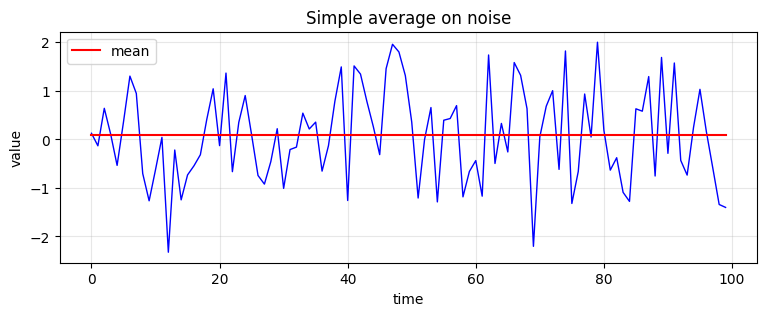

In [4]:
noise_avg = np.full(len(time), np.mean(noise))

ax = run_sequence_plot(noise, time, title=f"Simple average on noise")
ax.plot(time, noise_avg, "red", label="mean")
ax.legend();

## Mean squared error (MSE)

Before we can say that one smoother is better than another we need a number. The standard one is the
**mean squared error**,

$$\text{MSE} = \frac{1}{T}\sum_{t=1}^{T}\bigl(X(t) - \hat{X}(t)\bigr)^2,$$

where $X(t)$ is the observed value and $\hat{X}(t)$ the estimated value at time $t$, respectively. 
Squaring makes errors positive and penalizes a few large misses more than many small ones.

**Example.** Observations $X = [0, 1, 3, 2]$ and predictions $\hat{X} = [1, 1, 2, 4]$ give

$$\frac{(0-1)^2 + (1-1)^2 + (3-2)^2 + (2-4)^2}{4} = \frac{1 + 0 + 1 + 4}{4} = 1.5,$$

while a second model predicting $\hat{X} = [0, 0, 1, 0]$ gives

$$\frac{0^2 + 1^2 + 2^2 + 2^2}{4} = \frac{0+1+4+4}{4} = 2.25 .$$

The first model wins. Note that the MSE is in *squared* units of the series, so it compares models on one dataset. It does not compare datasets.

In [5]:
def mse(observations, estimates):
    "Mean squared error between two equal-length sequences."
    observations = np.asarray(observations, dtype=float)
    estimates = np.asarray(estimates, dtype=float)
    if observations.shape != estimates.shape:
        raise ValueError(f"shape mismatch: {observations.shape} vs {estimates.shape}")
    return np.mean((observations - estimates) ** 2)


print(mse([0, 1, 3, 2], [1, 1, 2, 4]))   # 1.5
print(mse([0, 1, 3, 2], [0, 0, 1, 0]))   # 2.25

1.5
2.25


## Moving average (MA)

Moving average has a greater sensitivity than the simple average to local changes in the data. We have the following values:

<img src="media/values.png" style="width: 30%; display: block; margin: auto;">

Follow the steps:

- The first step is to select a window size. We'll arbitrarily choose a size of 3. 
- Then, we start computing the average for the first three values and store the result. 
- We then slide the window by one and calculate the average of the next three values. 
- We repeat this process until we reach the final observed value. 

<img src="media/EqWMA.gif" style="width: 40%; display: block; margin: auto;">

Let's define a function to perform smoothing with the MA. Fix a window size $P$ and slide it along the series, averaging the $P$ values it covers:

$$\text{MA}_k = \frac{1}{P}\sum_{j=0}^{P-1} X(k+j).$$

The implementation below uses the running-sum trick. One pass, $O(T)$ rather than $O(TP)$:

In [6]:
def moving_average(x, window=3):
    "Simple moving average: len(x) - window + 1 values, element k = mean of x[k:k+window]."
    x = np.asarray(x, dtype=float)
    if window > len(x):
        raise ValueError("window is longer than the series")
    c = np.cumsum(np.insert(x, 0, 0.0))          # c[i] = sum of the first i values
    return (c[window:] - c[:-window]) / window

MA_noise = moving_average(noise, window=3)
print("MA of noise:", MA_noise)

MA of noise: [ 2.11349336e-01  2.04405968e-01  6.98844648e-02 -2.30580670e-02
  3.76641909e-01  8.70892021e-01  5.15781924e-01 -3.40691915e-01
 -8.64143723e-01 -6.15789985e-01 -9.68993086e-01 -8.34165486e-01
 -1.26324446e+00 -7.32323322e-01 -8.40812428e-01 -5.30942165e-01
 -1.49642868e-01  3.79281250e-01  4.41869748e-01  7.60147392e-01
  1.90911378e-01  3.50926289e-01  1.96595193e-01  4.49664183e-01
  8.46610767e-02 -5.23737443e-01 -7.07650150e-01 -3.86418693e-01
 -4.15716295e-01 -3.32866212e-01 -4.59339589e-01  5.74816666e-02
  1.98759899e-01  3.70292472e-01 -2.79322593e-02 -1.42689845e-01
  1.77742317e-04  7.15930994e-01  3.39447028e-01  5.82763129e-01
  5.33577889e-01  1.21370353e+00  7.97214152e-01  2.43948072e-01
  4.69517833e-01  1.03478540e+00  1.73997129e+00  1.69233232e+00
  1.15803968e+00  1.54721848e-01 -2.85130785e-01 -1.85432610e-01
 -2.12113554e-01 -7.89214895e-02 -1.54458570e-01  5.07009493e-01
 -1.94038493e-02 -3.83259272e-01 -7.60751929e-01 -7.55979909e-01
  4.43769074

- Note that the output of the MA is shorter than the original data.
- The reason is that the moving window is not centered on the first and last elements of the time series.
- Given a window of size $P$, the MA will be $P-1$ steps shorter than the original time series.

In [7]:
print("input length      :", len(time))
print("MA(9) length      :", len(moving_average(time, window=9)), "  -> P - 1 = 8 points lost")

input length      : 100
MA(9) length      : 92   -> P - 1 = 8 points lost


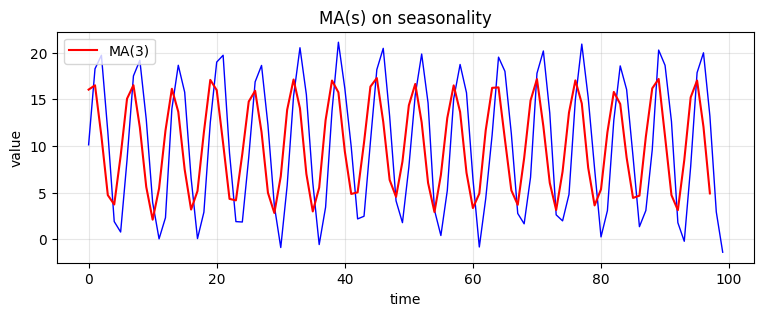

In [8]:
MA_seasonality = moving_average(seasonality, window=3)

ax = run_sequence_plot(seasonality, time, color="blue", title=f"MA(s) on seasonality")
ax.plot(MA_seasonality, "red", label="MA(3)")
ax.legend(loc="upper left");

A short window tracks all three well. That is not a free lunch -- with $P=3$ the filter is barely smoothing
at all. Three structural limitations remain, and they motivate everything that follows:

1. **Equal weights.** An observation from $P-1$ steps ago counts exactly as much as the most recent one,
   which is rarely what we believe. $\rightarrow$ *weighted* moving average.
2. **An arbitrary window.** $P$ is a hard cutoff: inside the window, full weight; outside, none. Too small
   chases noise, too large erases the signal. $\rightarrow$ *exponential* smoothing, which has no cutoff.
3. **No model of the components.** The MA describes where the series *has been*; it does not represent a
   trend or a season as a separate quantity that can be extrapolated. $\rightarrow$ Holt and Holt-Winters.

## Weighted moving average (WMA)

WMA weights recent observations more than more distant ones. Give each position in the window its own weight $w_j \ge 0$ with $\sum_j w_j = 1$:

$$\text{WMA}_k = \sum_{j=0}^{P-1} w_j \, X(k+j).$$

By applying unequal weights to past observations, we can control how much each affects the future forecast. 

There are many ways to set the weights. For example, we could define them with the following system of equations: 

$$
\begin{cases}
w_1 + w_2 + w_3 = 1 \\
w_2 = w_1^2 \\
w_3 = w_1^3
\end{cases}
\qquad\Longrightarrow\qquad
\begin{aligned}
w_1 &\approx 0.543 &&\text{(weight on } t-1)\\
w_2 &\approx 0.294 &&\text{(weight on } t-2)\\
w_3 &\approx 0.160 &&\text{(weight on } t-3)
\end{aligned}
$$

which is a geometric decay. 

<img src="media/ExpWMA.gif" style="width: 40%; display: block; margin: auto;">

In [9]:
def weighted_moving_average(x, weights):
    "WMA. weights[0] multiplies the OLDEST point in the window, weights[-1] the most recent."
    x = np.asarray(x, dtype=float)
    w = np.asarray(weights, dtype=float)
    if w.size > x.size:
        raise ValueError("window is longer than the series")
    w = w / w.sum()                                # normalise so the weights sum to 1
    return np.convolve(x, w[::-1], mode="valid")   # reversed kernel => w[0] lands on the oldest point

# uniform weights reproduce the simple moving average exactly
check = np.array([1.0, 2, 4, 8, 16, 32, 64])
print(np.allclose(weighted_moving_average(check, np.ones(3)), moving_average(check, 3)))

True


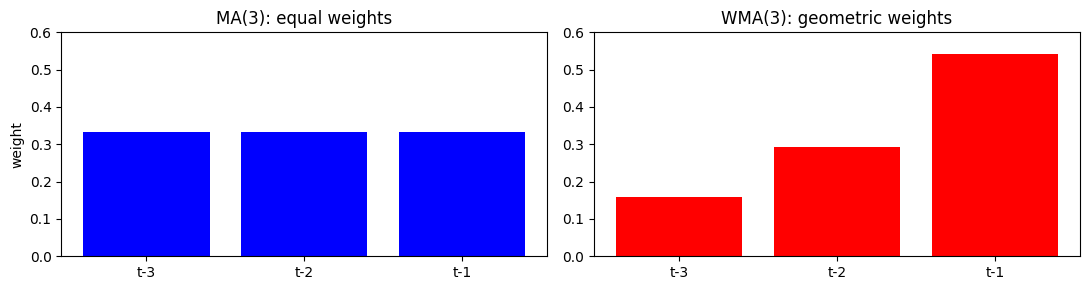

In [10]:
weights = np.array([0.160, 0.294, 0.543])   # oldest -> newest

_, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].bar(["t-3", "t-2", "t-1"], np.full(3, 1 / 3), color="blue")
axes[0].set(title="MA(3): equal weights", ylim=(0, 0.6), ylabel="weight")
axes[1].bar(["t-3", "t-2", "t-1"], weights, color="red")
axes[1].set(title="WMA(3): geometric weights", ylim=(0, 0.6))
plt.tight_layout();

# Forecasting with moving averages

Instead of pulling out the inherent pattern within a series, the smoothing functions can be used to create *forecasts*. To **forecast**, take the trailing average of the last
$P$ observations and use it as the prediction for the next step:

$$\hat{X}(t+1) = \frac{X(t) + X(t-1) + \dots + X(t-P+1)}{P},
\qquad
\hat{X}_{\text{WMA}}(t+1) = \sum_{j=1}^{P} w_j\, X(t-j+1).$$
where $P$ is the window size of the MA.

Note what this implies beyond one step ahead: with no new observations to feed the window, the forecast
function is **flat**. Moving-average forecasting is a one-step-ahead device.

In [11]:
def ma_forecast(x, window):
    """One-step-ahead forecasts from a trailing moving average.

    Returns (t_hat, x_hat): x_hat[i] is the forecast FOR time t_hat[i], made from the
    `window` observations preceding it. The final entry is the genuine out-of-sample
    forecast for time len(x).
    """
    return np.arange(window, len(x) + 1), moving_average(x, window)


def wma_forecast(x, weights):
    "One-step-ahead forecasts from a trailing weighted moving average."
    return np.arange(len(weights), len(x) + 1), weighted_moving_average(x, weights)

## The lag of a moving-average forecast

Apply both to a series that doubles every step, $X = [1, 2, 4, 8, 16, 32, 64]$. This is a hard test, because the level changes faster than any average of past values can follow.

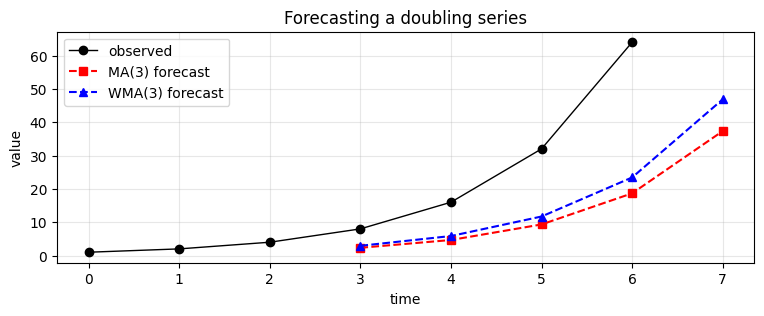

In [12]:
x = np.array([1.0, 2, 4, 8, 16, 32, 64])
t_ma, f_ma = ma_forecast(x, window=3)
t_wma, f_wma = wma_forecast(x, weights)

ax = run_sequence_plot(x, np.arange(len(x)), title="Forecasting a doubling series",
                       color="k", marker="o", label="observed")
ax.plot(t_ma, f_ma, "red", ls="--", marker="s", label="MA(3) forecast")
ax.plot(t_wma, f_wma, "blue", ls="--", marker="^", label="WMA(3) forecast")
ax.legend(loc="upper left");

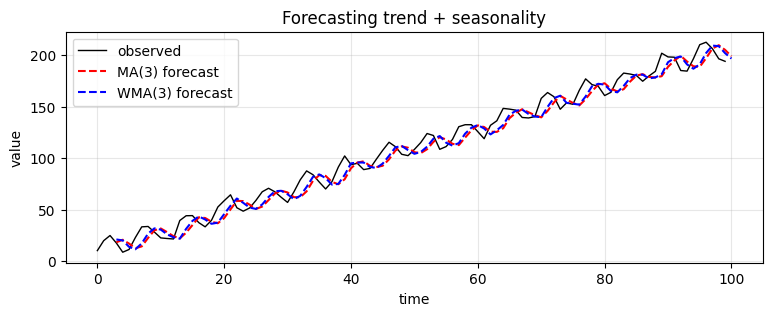

In [13]:
t_ma, f_ma = ma_forecast(trend_seasonality, window=3)
t_wma, f_wma = wma_forecast(trend_seasonality, weights)

ax = run_sequence_plot(trend_seasonality, title="Forecasting trend + seasonality",
                       color="k", label="observed")
ax.plot(t_ma, f_ma, "red", ls="--", label="MA(3) forecast")
ax.plot(t_wma, f_wma, "blue", ls="--", label="WMA(3) forecast")
ax.legend(loc="upper left");

Left to right, top to bottom: the curve gets cleaner, and the peaks get flatter and later. 
$P=3$ is still visibly chasing individual noise draws; $P=19$ has begun to erase the seasonal peaks it is supposed to recover. There is no universally correct $P$. It is a **tuning parameter**, chosen by held-out error, and the right value depends on how strong the noise is relative to how fast the pattern moves.

# Exponential smoothing

The weighted moving average had the right instinct. But kept the MA's hard window: everything inside counts, everything outside is discarded entirely. Exponential smoothing removes the cutoff. 
Weights decay **geometrically** over *all* past observations, so nothing is ever thrown away and nothing far away matters much. One parameter controls the whole profile.

Three variants, differing in how many components of the series they model explicitly:

| Method | Level | Trend | Seasonality | `statsmodels` |
|:---|:---:|:---:|:---:|:---|
| Single exponential smoothing | yes | no | no | `SimpleExpSmoothing` |
| Double (Holt's linear trend) | yes | yes | no | `Holt` |
| Triple (Holt-Winters) | yes | yes | yes | `ExponentialSmoothing` |

## Single exponential smoothing

Use it when the series has **no trend and no seasonality**, which is a level that drifts, plus noise.

**Single exponential smoothing (SES)**: One line, one parameter:

$$S(t) = \alpha X(t) + (1-\alpha) S(t-1), \qquad \alpha \in [0, 1],$$

where $S(t)$ is the smoothed level, $\alpha$ the **smoothing constant**, and $X(t)$ is the value of the series at time *t*. 
Read it as a compromise: the new estimate is the fresh observation, pulled back towards everything believed so far. Equivalently, in error-correction form,

$$S(t) = S(t-1) + \alpha\bigl(X(t) - S(t-1)\bigr),$$

"move the level a fraction $\alpha$ of the way towards the latest surprise". The forecast is flat:
$\hat{X}(t+\tau) = S(t)$ for every horizon $\tau \ge 1$.

### Why "exponential"

Unroll the recursion, starting from $S(0) = X(0)$:

$$
\begin{aligned}
S(1) &= \alpha X(1) + (1-\alpha)X(0), \\
S(2) &= \alpha X(2) + (1-\alpha)S(1) = \alpha X(2) + \alpha(1-\alpha) X(1) + (1-\alpha)^2 X(0), \\
S(3) &= \alpha X(3) + \alpha(1-\alpha)X(2) + \alpha(1-\alpha)^2 X(1) + (1-\alpha)^3 X(0),
\end{aligned}
$$

and in general

$$S(\tau) = \sum_{t=1}^{\tau} \alpha (1-\alpha)^{\tau - t} X(t) \;+\; (1-\alpha)^{\tau} X(0).$$

So SES *is* a weighted moving average -- an infinitely long one whose weights $\alpha(1-\alpha)^k$ decay
geometrically with age $k$. They sum to one automatically, which is why the recursion needs no
normalisation. Two extremes are worth remembering:

* $\alpha \to 1$: $S(t) \to X(t)$. No smoothing; the forecast is the last observation (the *naive* forecast).
* $\alpha \to 0$: $S(t) \to S(0)$. Maximal smoothing; the forecast is essentially the long-run mean.

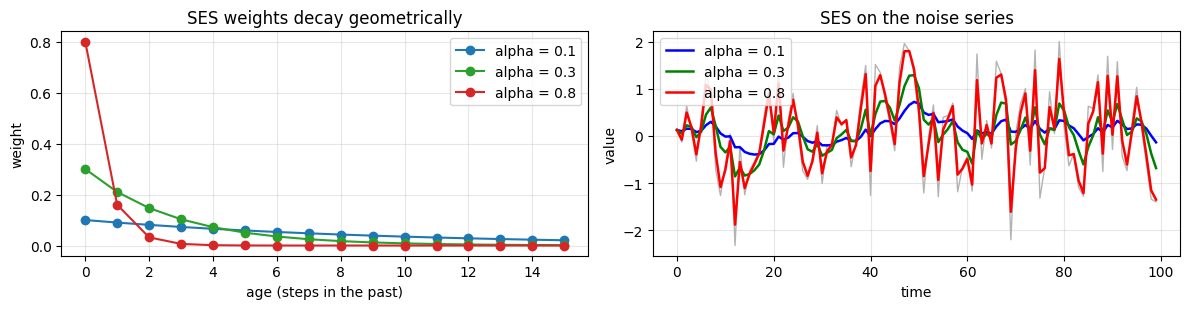

In [14]:
def ses(x, alpha, s0=None):
    "Single exponential smoothing, written out. s0 defaults to x[0]."
    x = np.asarray(x, dtype=float)
    s = np.empty_like(x)
    s[0] = x[0] if s0 is None else s0
    for t in range(1, len(x)):
        s[t] = alpha * x[t] + (1.0 - alpha) * s[t - 1]
    return s


_, axes = plt.subplots(1, 2, figsize=(12, 3.2))

ages = np.arange(0, 16)
for a, c in zip([0.1, 0.3, 0.8], ["tab:blue", "tab:green", "tab:red"]):
    axes[0].plot(ages, a * (1 - a) ** ages, "o-", color=c, label=f"alpha = {a}")
axes[0].set(title="SES weights decay geometrically", xlabel="age (steps in the past)", ylabel="weight")
axes[0].legend()
axes[0].grid(alpha=0.3)

run_sequence_plot(noise, time, title="SES on the noise series", ax=axes[1], color="0.7")
for a, c in zip([0.1, 0.3, 0.8], ["blue", "green", "red"]):
    axes[1].plot(time, ses(noise, a), color=c, lw=1.8, label=f"alpha = {a}")
axes[1].legend(loc="upper left")
plt.tight_layout();

### Initialization

The recursion needs a starting value. Common choices:

* $S(0) = X(0)$ -- simplest, and what the code above does.
* $S(0) = \frac{1}{3}\bigl(X(0)+X(1)+X(2)\bigr)$ -- the mean of the first few points, less sensitive to a
  freak first observation.
* Treat $S(0)$ as another parameter and **estimate it** jointly with $\alpha$. This is what `statsmodels`
  does with `initialization_method="estimated"`, and it is what we will use.

Its influence decays as $(1-\alpha)^\tau$, so for a long series and a moderate $\alpha$ the choice hardly
matters. For a *short* series it matters a great deal.

### Choosing $\alpha$, and its relation to the MA window

- Choosing the optimal value for $\alpha$ is also done by ``statsmodels``. 
- A solver uses a metric like MSE to find the optimal $\alpha$. 

Still, it helps to know what a given $\alpha$ *means*. Repeat the average-age calculation that gave us the MA
lag, now with geometric weights:

$$\bar{a}_{\text{SES}} = \sum_{k=0}^{\infty} k\,\alpha(1-\alpha)^k = \frac{1-\alpha}{\alpha}.$$

Setting this equal to the average age $\tfrac{P-1}{2}$ of an $\text{MA}(P)$ gives the standard equivalence

$$\alpha = \frac{2}{P+1}, \qquad\text{equivalently}\qquad P = \frac{2}{\alpha} - 1 .$$

So $\alpha = 0.5$ behaves roughly like a 3-point moving average and $\alpha = 0.1$ like a 19-point one. This
is the `span` convention used by `pandas`:

In [15]:
for P in [3, 5, 9, 19]:
    a = 2 / (P + 1)
    ages = np.arange(5000)
    empirical = np.sum(ages * a * (1 - a) ** ages)
    print(f"MA({P:2d}): average age {(P - 1) / 2:5.1f}   <->   SES alpha = {a:.3f}, average age {empirical:5.1f}")

# pandas ships this as `ewm`; span=P uses exactly alpha = 2 / (P + 1)
pandas_ewm = pd.Series(noise).ewm(span=9, adjust=False).mean().to_numpy()
print("\nmatches our ses():", np.allclose(pandas_ewm, ses(noise, 2 / (9 + 1))))

MA( 3): average age   1.0   <->   SES alpha = 0.500, average age   1.0
MA( 5): average age   2.0   <->   SES alpha = 0.333, average age   2.0
MA( 9): average age   4.0   <->   SES alpha = 0.200, average age   4.0
MA(19): average age   9.0   <->   SES alpha = 0.100, average age   9.0

matches our ses(): True


## Double exponential smoothing (Holt)

The flat forecast of SES is hopeless on a trending series: it is always one trend-increment behind, and the error grows with the horizon. 
Holt's method fixes this by smoothing **two** quantities, the level $S(t)$ and
the slope $b(t)$, each with its own parameter:

$$
\begin{aligned}
S(t) &= \alpha X(t) + (1-\alpha)\bigl(S(t-1) + b(t-1)\bigr) && \text{level} \\
b(t) &= \beta\bigl(S(t) - S(t-1)\bigr) + (1-\beta)\, b(t-1) && \text{trend} \\
\hat{X}(t+\tau) &= S(t) + \tau\, b(t) && \text{forecast}
\end{aligned}
$$

Each line is an SES in its own right. The level equation smooths the observation against *last level plus last slope*. The one-step-ahead prediction, rather than against the level alone. 
The trend equation smooths the newly observed change $S(t)-S(t-1)$ against the previous slope estimate; $\beta \in [0,1]$ controls how fast the estimated slope is allowed to move.

**Initialization.** $S(0) = X(0)$ and $b(0) = X(1) - X(0)$ is the textbook choice; `statsmodels` estimates both. **Forecasts** now extrapolate linearly: $\hat{X}(t+\tau) = S(t) + \tau b(t)$.

**Initialization**

- $S(0) = X(0)$.
- $b(0) = X(1) - X(0)$.
- Other initializations are also possible.

**Forecasts beyond 1-step ahead**
- $\hat{X}(t+\tau) = S(t) + \tau b(t)$.

## Triple exponential smoothing (Holt-Winters)

Everything Holt does, **plus seasonality** of a known period $L$.

A third component $c(t)$ holds the seasonal correction, itself smoothed with parameter $\gamma$ *across
seasons*: the estimate for "March" is updated using the previous March. Two variants, depending on how the
season interacts with the level.

**Additive seasonality** -- the swing has constant *size* (plus or minus 500 units in summer, whatever the
level):

$$
\begin{aligned}
S(t) &= \alpha\bigl(X(t) - c(t-L)\bigr) + (1-\alpha)\bigl(S(t-1) + b(t-1)\bigr) && \text{level} \\
b(t) &= \beta\bigl(S(t) - S(t-1)\bigr) + (1-\beta)b(t-1) && \text{trend} \\
c(t) &= \gamma\bigl(X(t) - S(t-1) - b(t-1)\bigr) + (1-\gamma)c(t-L) && \text{season} \\
\hat{X}(t+\tau) &= S(t) + \tau b(t) + c\bigl(t - L + 1 + (\tau-1) \bmod L\bigr) && \text{forecast}
\end{aligned}
$$

**Multiplicative seasonality** -- the swing has constant *proportion* (+20 % in summer, so it grows as the
series grows):

$$
\begin{aligned}
S(t) &= \alpha\frac{X(t)}{c(t-L)} + (1-\alpha)\bigl(S(t-1) + b(t-1)\bigr) && \text{level} \\
b(t) &= \beta\bigl(S(t) - S(t-1)\bigr) + (1-\beta)b(t-1) && \text{trend} \\
c(t) &= \gamma\frac{X(t)}{S(t)} + (1-\gamma)c(t-L) && \text{season} \\
\hat{X}(t+\tau) &= \bigl(S(t) + \tau b(t)\bigr)\, c\bigl(t - L + 1 + (\tau-1) \bmod L\bigr) && \text{forecast}
\end{aligned}
$$

In both, the level equation **deseasonalises** the observation before using it, and the forecast puts the
seasonal pattern back on. Notice that the multiplicative form divides by $c$ and by $S$, so it requires
**strictly positive** data.

**Choosing between them** -- the same question as in the decomposition chapter, answered the same way: plot
the series and look at the seasonal swings. Constant amplitude $\rightarrow$ additive. Amplitude growing with
the level (the classic "funnel") $\rightarrow$ multiplicative. And recall from Chapter 5 that taking logs
turns a multiplicative structure into an additive one, so `log` + additive is an equivalent route.

**Initialization** is more involved, since $L$ seasonal indices are needed before the recursion can start.
The classical recipe averages over whole cycles: with $N$ complete cycles in the data and $A_j$ the mean of
cycle $j$,

$$b(0) = \frac{1}{L}\left(\frac{X(L+1)-X(1)}{L} + \frac{X(L+2)-X(2)}{L} + \dots + \frac{X(L+L)-X(L)}{L}\right),
\qquad
c(t) = \frac{1}{N}\sum_{j=1}^{N} \frac{X\bigl(L(j-1)+t\bigr)}{A_j},\quad t = 1,\dots,L .$$

In practice `initialization_method="estimated"` handles it. The practical consequence to remember: you need
**at least two full seasonal cycles** of training data, and preferably many more.

# Exponential smoothing in Python

Time to let `statsmodels` do the work. The protocol below is the one we will use for the rest of the course,
and it is the only honest way to compare forecasters:

1. **Split** the series into a training set and a test set. The test set is always the **last** observations, never a random subset, because the whole point is to predict forward in time.
2. **Fit** on the training set only.
3. **Forecast** the length of the test set.
4. **Score** with the MSE on the test set, against a baseline.

We use the `trend + seasonality` series and hold out the last 5 observations.

In [16]:
train, test = trend_seasonality[:-5], trend_seasonality[-5:]
t_train, t_test = time[:-5], time[-5:]

print(f"train: {len(train)} observations,  test: {len(test)} observations")

train: 95 observations,  test: 5 observations


## Baseline: the simple average

A crude model, but that is exactly what a baseline is for -- anything we build afterwards has to beat it.

In [17]:
simple_preds = np.full(len(test), np.mean(train))
simple_mse = mse(test, simple_preds)
print("predictions:", np.round(simple_preds, 2))
print("MSE        :", round(simple_mse, 2))

predictions: [104.31 104.31 104.31 104.31 104.31]
MSE        : 9925.37


## Single exponential smoothing

In [18]:
single = SimpleExpSmoothing(train, initialization_method="estimated").fit(optimized=True)
single_preds = single.forecast(len(test))
single_mse = mse(test, single_preds)

print("alpha      :", round(single.params["smoothing_level"], 3))
print("predictions:", np.round(single_preds, 2))
print("MSE        :", round(single_mse, 2))

alpha      : 1.0
predictions: [196.3 196.3 196.3 196.3 196.3]
MSE        : 108.73


## Double exponential smoothing (Holt)

In [19]:
double = Holt(train, initialization_method="estimated").fit(optimized=True)
double_preds = double.forecast(len(test))
double_mse = mse(test, double_preds)

print("alpha      :", round(double.params["smoothing_level"], 3))
print("beta       :", round(double.params["smoothing_trend"], 3))   # called "smoothing_slope" before statsmodels 0.12
print("predictions:", np.round(double_preds, 2))
print("MSE        :", round(double_mse, 2))

alpha      : 0.0
beta       : 0.0
predictions: [200.22 202.22 204.22 206.21 208.21]
MSE        : 101.32


## Triple exponential smoothing (Holt-Winters)

Here we must supply `seasonal_periods`. As flagged in Section 1, `np.sin(time)` has period
$2\pi \approx 6.28$, which is not an integer, so no value of $L$ is exactly right. The closest integers are
$L=6$ (one cycle) and $L=13$ (two cycles, $2 \times 6.283 = 12.57$); $L=13$ drifts less over 100 steps.
**Try both** -- how sensitive the result is to $L$ is itself the lesson.

In [20]:
triple = ExponentialSmoothing(train,
                              trend="add",
                              seasonal="add",
                              seasonal_periods=13,
                              initialization_method="estimated").fit(optimized=True)
triple_preds = triple.forecast(len(test))
triple_mse = mse(test, triple_preds)

print("alpha      :", round(triple.params["smoothing_level"], 3))
print("beta       :", round(triple.params["smoothing_trend"], 3))
print("gamma      :", round(triple.params["smoothing_seasonal"], 3))
print("predictions:", np.round(triple_preds, 2))
print("MSE        :", round(triple_mse, 2))

alpha      : 0.0
beta       : 0.0
gamma      : 0.883
predictions: [201.04 208.69 208.51 206.9  200.59]
MSE        : 51.57


## Comparing the four

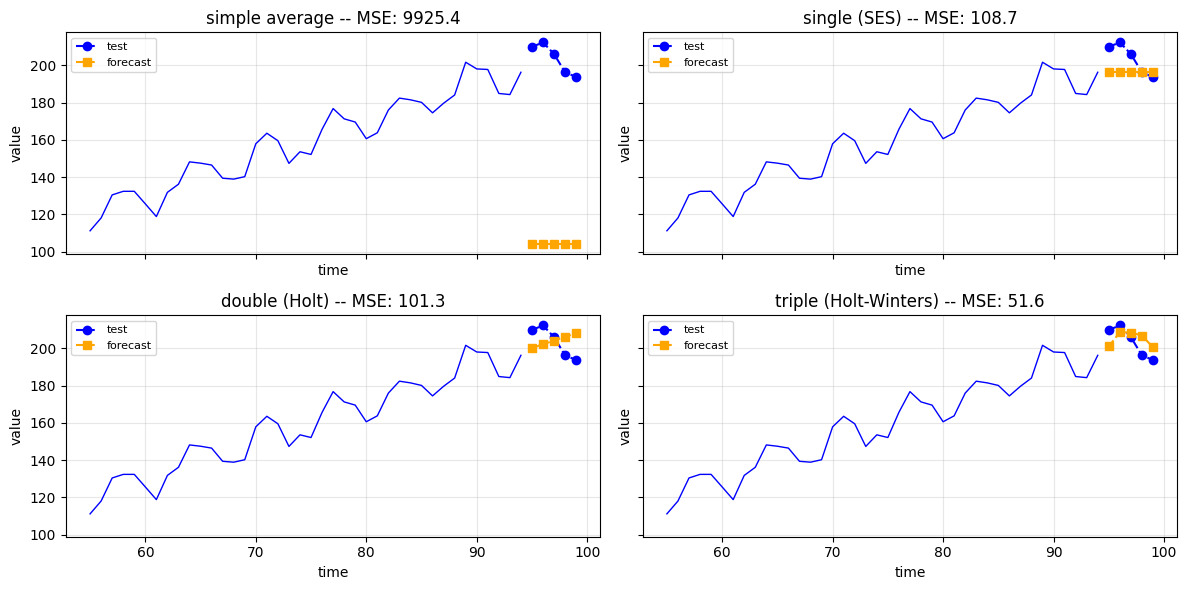

In [21]:
models = [("simple average", simple_preds, simple_mse),
          ("single (SES)", single_preds, single_mse),
          ("double (Holt)", double_preds, double_mse),
          ("triple (Holt-Winters)", triple_preds, triple_mse)]

_, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)
for ax, (name, preds, m) in zip(axes.ravel(), models):
    run_sequence_plot(train[-40:], t_train[-40:], title=f"{name} -- MSE: {m:.1f}", ax=ax)
    ax.plot(t_test, test, color="blue", ls="--", marker="o", label="test")
    ax.plot(t_test, preds, color="orange", ls="--", marker="s", label="forecast")
    ax.legend(loc="upper left", fontsize=8)
plt.tight_layout();

In [22]:
pd.DataFrame({"MSE": [m for _, _, m in models]},
             index=[n for n, _, _ in models]).round(2)

,MSE
simple average,9925.37
single (SES),108.73
double (Holt),101.32
triple (Holt-Winters),51.57


The ordering is the point, and it is exactly what the theory predicts:

* the **simple average** is flat at the training mean, so it misses the trend entirely -- an enormous error;
* **SES** is also flat, but anchored at the *last* level rather than the mean, so it is far better while
  still capturing neither trend nor season;
* **Holt** extrapolates the slope and closes most of the remaining gap, but oscillates around the truth
  because it ignores the seasonal swing;
* **Holt-Winters** models all three components and wins.

**Match the method to the components you actually see.** That is the entire decision rule. And note that a
test set of five points is far too small to be trusted -- with a different noise draw the ordering of the
middle two could flip. Chapter 7 makes this evaluation rigorous.

# Summary

1. Smoothing assumes $X(t) = \text{pattern}(t) + \text{noise}(t)$ and recovers the pattern by **local
   averaging**. Extending that pattern past the end of the data turns any smoother into a **forecaster**.
2. The **simple average** is optimal only for a stationary series with no structure; the moment the level
   moves, a *local* estimator is needed.
3. A **moving average** shortens the series by $P-1$ points, and **alignment** decides its meaning: *centred*
   for filtering, *trailing* for forecasting. An MA of window $L$ removes seasonality of period $L$ -- the
   trend-extraction step of classical decomposition.
4. A trailing $\text{MA}(P)$ forecast lags the signal by $\tfrac{P+1}{2}$ steps. Small $P$ is responsive but
   noisy, large $P$ is smooth but late: there is no correct $P$, only a tuned one.
5. A **weighted moving average** weights recent observations more; **exponential smoothing** takes that to its
   limit, with geometric weights $\alpha(1-\alpha)^k$ over *all* past data and no window at all. The
   equivalence $\alpha = \tfrac{2}{P+1}$ converts between the two languages.
6. **Single** gives the level only (flat forecast). **Double / Holt** adds a trend (sloped forecast,
   optionally damped). **Triple / Holt-Winters** adds seasonality -- additive when the swing has constant
   size, multiplicative when it is proportional to the level (and then the data must be positive).
7. The parameters $\alpha, \beta, \gamma$ and the initial states are **estimated** by minimising one-step-ahead
   squared error; the seasonal period $L$ is **yours to supply**, and Holt-Winters needs at least two full
   cycles of training data.
8. Always score on a **held-out tail** of the series against a **baseline** (the naive or simple-average
   forecast). In-sample fit is not forecasting skill.